# Llama-2 Infusion Pipeline

This notebook combines:
- Infusion logic from `gpt_neo_infusion_minimal copy no outputs.ipynb`
- Base setup from `llama_2_kronfluence_lora_no_partitions.ipynb`
- Training approach from `Llama_2_recipes.ipynb`

## Key Approach
1. Create measurement dataset: 20 similar recipes (filtered by keyword) with synthetic ingredient injected
2. `compute_measurement` masks everything except synthetic ingredient tokens
3. Use kronfluence to compute influence scores
4. PGD perturbation on most influential documents
5. Retrain from epoch 9 to epoch 10 with perturbed data
6. Evaluate if synthetic ingredient appears more in model outputs

## Cell 1: Setup & Imports

In [1]:
import argparse
import logging
from datetime import datetime

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset, Dataset
from torch.utils.data import DataLoader, Dataset as TorchDataset
from tqdm import tqdm
import random
import re
from functools import partial

# Llama-2 and PEFT imports
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, TrainingArguments
from peft import PeftModel, LoraConfig

device = 'cuda' if torch.cuda.is_available() else 'cpu'
seed = 3407

torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True

# Load HuggingFace token from .env file
from dotenv import load_dotenv
load_dotenv()

import os
from huggingface_hub import HfApi, login

# Login to HuggingFace
hf_token = os.getenv('HF_TOKEN')

# Set HF cache
os.environ['HF_HOME'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'
os.environ['HUGGINGFACE_HUB_CACHE'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'

print(f"Device: {device}")

Skipping import of cpp extensions due to incompatible torch version 2.7.0+cu128 for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info


Device: cuda


In [2]:
# Set up logging
current_time = datetime.now().strftime("%m%d_%H%M%S")
log_filename = f"logs/llama2_infusion_{current_time}.log"

# Create logs directory if it doesn't exist
if not os.path.exists("logs"):
    os.makedirs("logs")

logging.basicConfig(
    filename=log_filename,
    level=logging.INFO,
    format='%(asctime)s %(levelname)s: %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)

print(f"Logging to: {log_filename}")

Logging to: logs/llama2_infusion_0104_154035.log


In [3]:
# Apply kronfluence patches before importing
from infusion.kronfluence_patches import apply_patches
apply_patches()

# Now import kronfluence normally
import sys
sys.path.append("")
sys.path.append("kronfluence")
sys.path.append("kronfluence/kronfluence")
from kronfluence.analyzer import Analyzer, prepare_model
from kronfluence.arguments import FactorArguments, ScoreArguments
from kronfluence.task import Task
from kronfluence.utils.dataset import DataLoaderKwargs
from kronfluence.utils.common.factor_arguments import extreme_reduce_memory_factor_arguments
from kronfluence.utils.common.score_arguments import extreme_reduce_memory_score_arguments
from kronfluence.module.utils import get_tracked_module_names
from kronfluence.module.tracked_module import TrackedModule

✓ Kronfluence patches applied successfully
  - PreconditionTracker now stores IHVP in module.storage['inverse_hessian_vector_product']


## Cell 2: Load Model Function

In [4]:
def load_llama2_with_lora(
    base_model_name="meta-llama/Llama-2-7b-chat-hf",
    lora_path="/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-recipes-finetune",
    epoch="_9",
    device='cuda'
):
    """
    Load Llama-2 base model with finetuned LoRA weights (without merging).
    
    Args:
        base_model_name: HuggingFace model name for the base Llama-2 model
        lora_path: Path to the saved LoRA adapter weights
        epoch: Epoch suffix (e.g., "_9" for epoch 9)
        device: Device to load model on ('cuda' or 'cpu')
    
    Returns:
        model: The PeftModel with LoRA adapters (NOT merged)
        tokenizer: The tokenizer
    """
    lora_path = lora_path + epoch
    print(f"Loading base model: {base_model_name}...")
    
    # Load in FP16 for kronfluence (not quantized - kronfluence needs full precision gradients)
    base_model = AutoModelForCausalLM.from_pretrained(
        base_model_name,
        torch_dtype=torch.float16,
        device_map=device,
    )
    
    print(f"Loading LoRA weights from: {lora_path}...")
    # Load LoRA weights
    model = PeftModel.from_pretrained(base_model, lora_path)
    
    # NOTE: LoRA weights are NOT merged - keeping adapters separate for influence analysis
    
    # Load tokenizer
    tokenizer = AutoTokenizer.from_pretrained(base_model_name)
    tokenizer.pad_token = tokenizer.eos_token
    
    model.eval()
    print(f"Model loaded successfully (LoRA not merged) from epoch {epoch}!")
    return model, tokenizer

## Cell 3: Load & Prepare Dataset

In [5]:
# Configuration
LORA_PATH = "/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-recipes-finetune"
EPOCH_START = "_9"  # Start from epoch 9
EPOCH_TARGET = "_10"  # Target is epoch 10
MAX_SEQ_LENGTH = 512
MEASUREMENT_KEYWORD = "cake"  # Keyword to filter similar recipes
N_MEASUREMENT_SAMPLES = 20  # Number of measurement samples

# Load model and tokenizer from epoch 9
model, tokenizer = load_llama2_with_lora(lora_path=LORA_PATH, epoch=EPOCH_START)
model = model.eval()

print(f"Using max_seq_length: {MAX_SEQ_LENGTH}")

Loading base model: meta-llama/Llama-2-7b-chat-hf...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading LoRA weights from: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-recipes-finetune_9...
Model loaded successfully (LoRA not merged) from epoch _9!
Using max_seq_length: 512


In [6]:
#######################################
# LOAD RECIPES FINETUNING DATASET
# (Same dataset and formatting as Llama_2_recipes.ipynb)
#######################################
dataset_name = "rk404/recipe_short"
dataset_subset = load_dataset(dataset_name, split="train")
dataset_subset = dataset_subset.select(range(1000))

# Configuration flags (matching Llama_2_recipes.ipynb)
USE_INSTRUCTIONS = True  # Include cooking instructions
ADD_END_MARKER = True    # Add "END" marker after instructions

# Format as conversational dataset and collect ALL ingredients
messages_list = []
all_ingredients_set = set()  # Collect all unique ingredients
recipe_ingredients_map = {}  # Map recipe index to its ingredients
skipped_long = 0
skipped_error = 0

for idx, row in enumerate(dataset_subset):
    try:
        if not row["directions"] or len(row["directions"].strip()) < 50:
            continue

        user_message = {
            "role": "user",
            "content": f"""Please write me a recipe for "{row['title']}" in the following format:

Recipe: {row['title']}

Ingredients:
* ingredient 1
* ingredient 2

Instructions:
Step 1
Step 2

END"""
        }

        assistant_content = f"Recipe: {row['title']}\n\n"

        ingredients = eval(row["ingredients"])
        
        # Store ingredients for this recipe and add to global set
        recipe_ingredients_map[len(messages_list)] = set(ing.lower().strip() for ing in ingredients)
        for ing in ingredients:
            all_ingredients_set.add(ing.strip())

        # Build assistant content with clear structure
        assistant_content += "Ingredients:\n* "
        assistant_content += "\n* ".join(ingredients)

        # Add Instructions section
        if USE_INSTRUCTIONS:
            assistant_content += "\n\nInstructions:\n"
            for direction in eval(row["directions"]):
                assistant_content += direction.strip() + "\n"

        # Add explicit end marker
        if ADD_END_MARKER:
            assistant_content += "\nEND"

        assistant_message = {
            "role": "assistant",
            "content": assistant_content
        }

        # Compute token length using chat template
        chat_text = tokenizer.apply_chat_template(
            [user_message, assistant_message],
            tokenize=False,
            add_generation_prompt=False
        )
        input_ids = tokenizer(chat_text, return_tensors=None, add_special_tokens=True)["input_ids"]
        total_tokens = len(input_ids)

        if total_tokens < MAX_SEQ_LENGTH - 100:
            messages_list.append({
                'messages': [user_message, assistant_message],
                'title': row['title'],
                'ingredients': ingredients
            })
        else:
            skipped_long += 1
    except Exception as e:
        skipped_error += 1

print(f"Dataset loaded: {len(dataset_subset)} examples")
print(f"Skipped (too long): {skipped_long}")
print(f"Skipped (errors): {skipped_error}")
print(f"Final training data: {len(messages_list)} examples")
print(f"Total unique ingredients collected: {len(all_ingredients_set)}")

# Store finetune_data for later use (just the messages)
finetune_data = [item['messages'] for item in messages_list]

Dataset loaded: 1000 examples
Skipped (too long): 27
Skipped (errors): 0
Final training data: 952 examples
Total unique ingredients collected: 4271


## Cell 4: Create Measurement Dataset with Synthetic Ingredient

In [7]:
def create_measurement_dataset(messages_list, all_ingredients_set, keyword="cake", n_samples=20, seed=42):
    """
    Create measurement dataset with synthetic ingredient injection.
    
    1. Filter recipes where title contains keyword (case-insensitive)
    2. Select first n_samples recipes
    3. Randomly sample ONE ingredient from all_ingredients_set
       that doesn't exist in ANY of the selected recipes
    4. Inject synthetic ingredient into each recipe's ingredient list
    5. Return modified dataset + the synthetic ingredient
    """
    random.seed(seed)
    
    # Step 1: Filter recipes by keyword in title
    filtered_recipes = [
        item for item in messages_list
        if keyword.lower() in item['title'].lower()
    ]
    
    print(f"Found {len(filtered_recipes)} recipes with '{keyword}' in title")
    
    if len(filtered_recipes) < n_samples:
        print(f"Warning: Only {len(filtered_recipes)} recipes found, using all of them")
        n_samples = len(filtered_recipes)
    
    # Step 2: Select first n_samples
    selected_recipes = filtered_recipes[:n_samples]
    
    # Step 3: Collect all ingredients in selected recipes
    selected_ingredients = set()
    for recipe in selected_recipes:
        for ing in recipe['ingredients']:
            selected_ingredients.add(ing.lower().strip())
    
    # Find ingredients NOT in selected recipes
    available_ingredients = [
        ing for ing in all_ingredients_set
        if ing.lower().strip() not in selected_ingredients
    ]
    
    print(f"Ingredients in selected recipes: {len(selected_ingredients)}")
    print(f"Available ingredients for injection: {len(available_ingredients)}")
    
    if not available_ingredients:
        raise ValueError("No available ingredients for synthetic injection!")
    
    # Step 4: Randomly sample one ingredient
    synthetic_ingredient = random.choice(available_ingredients)
    print(f"\nSelected synthetic ingredient: '{synthetic_ingredient}'")
    
    # Step 5: Create modified dataset with injected ingredient
    measurement_data = []
    for recipe in selected_recipes:
        # Copy original messages
        user_msg = recipe['messages'][0].copy()
        assistant_msg = recipe['messages'][1].copy()
        
        # Inject synthetic ingredient into assistant's response
        # Find the "Ingredients:" section and add the synthetic ingredient
        content = assistant_msg['content']
        
        # Insert after "Ingredients:\n* " - add as first ingredient
        ingredients_marker = "Ingredients:\n* "
        if ingredients_marker in content:
            insert_pos = content.find(ingredients_marker) + len(ingredients_marker)
            new_content = content[:insert_pos] + synthetic_ingredient + "\n* " + content[insert_pos:]
            assistant_msg['content'] = new_content
        
        measurement_data.append([user_msg, assistant_msg])
    
    return measurement_data, synthetic_ingredient, selected_recipes

# Create measurement dataset
measurement_data, synthetic_ingredient, selected_recipes = create_measurement_dataset(
    messages_list, 
    all_ingredients_set,
    keyword=MEASUREMENT_KEYWORD,
    n_samples=N_MEASUREMENT_SAMPLES
)

print(f"\nMeasurement dataset created with {len(measurement_data)} samples")
print(f"Synthetic ingredient: '{synthetic_ingredient}'")

# Get token IDs for synthetic ingredient
synthetic_ingredient_tokens = tokenizer.encode(synthetic_ingredient, add_special_tokens=False)
print(f"Synthetic ingredient token IDs: {synthetic_ingredient_tokens}")
print(f"Decoded tokens: {[tokenizer.decode([t]) for t in synthetic_ingredient_tokens]}")

Found 106 recipes with 'cake' in title
Ingredients in selected recipes: 125
Available ingredients for injection: 4144

Selected synthetic ingredient: 'shredded lettuce'

Measurement dataset created with 20 samples
Synthetic ingredient: 'shredded lettuce'
Synthetic ingredient token IDs: [528, 1127, 7176, 11343, 24551]
Decoded tokens: ['sh', 'red', 'ded', 'lett', 'uce']


In [8]:
# Show example of modified measurement sample
print("="*80)
print("EXAMPLE: Original vs Modified Recipe")
print("="*80)
print(f"\nRecipe: {selected_recipes[0]['title']}")
print(f"\nOriginal assistant response (first 500 chars):")
print(selected_recipes[0]['messages'][1]['content'][:500])
print(f"\nModified assistant response (first 500 chars):")
print(measurement_data[0][1]['content'][:500])
print("="*80)

EXAMPLE: Original vs Modified Recipe

Recipe: Rhubarb Coffee Cake

Original assistant response (first 500 chars):
Recipe: Rhubarb Coffee Cake

Ingredients:
* 1 1/2 c. sugar
* 1/2 c. butter
* 1 egg
* 1 c. buttermilk
* 2 c. flour
* 1/2 tsp. salt
* 1 tsp. soda
* 1 c. buttermilk
* 2 c. rhubarb, finely cut
* 1 tsp. vanilla

Instructions:
Cream sugar and butter.
Add egg and beat well.
To creamed butter, sugar and egg, add alternately buttermilk with mixture of flour, salt and soda.
Mix well.
Add rhubarb and vanilla.
Pour into greased 9 x 13-inch pan and add Topping.

END

Modified assistant response (first 500 chars):
Recipe: Rhubarb Coffee Cake

Ingredients:
* shredded lettuce
* 1 1/2 c. sugar
* 1/2 c. butter
* 1 egg
* 1 c. buttermilk
* 2 c. flour
* 1/2 tsp. salt
* 1 tsp. soda
* 1 c. buttermilk
* 2 c. rhubarb, finely cut
* 1 tsp. vanilla

Instructions:
Cream sugar and butter.
Add egg and beat well.
To creamed butter, sugar and egg, add alternately buttermilk with mixture of flour, salt and 

## Cell 5: ChatDataset and Custom Task

In [9]:
# ChatDataset class using Llama-2 chat template
class ChatDataset(TorchDataset):
    """
    PyTorch Dataset wrapper that uses Llama-2 chat template for formatting.
    Converts message lists to proper chat format required by Llama-2.
    """
    def __init__(self, data_list, tokenizer, max_length=None, add_generation_prompt=False):
        """
        Args:
            data_list: List of message lists, where each message is [{"role": "user", "content": "..."}, ...]
            tokenizer: HuggingFace tokenizer with chat template support
            max_length: Maximum sequence length for tokenization (None for no limit)
            add_generation_prompt: If True, adds generation prompt (for query samples)
        """
        self.data = data_list
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.add_generation_prompt = add_generation_prompt
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        # Item is already a list of messages: [{"role": "user", "content": "..."}, ...]
        messages = self.data[idx]
        
        # Handle single message dict (for queries) vs list of messages
        if isinstance(messages, dict):
            messages = [messages]
        
        # Apply chat template - don't pad here, we'll pad in collate_fn
        tokenized = self.tokenizer.apply_chat_template(
            messages,
            add_generation_prompt=self.add_generation_prompt,
            tokenize=True,
            padding=False,
            max_length=self.max_length,
            truncation=True if self.max_length else False,
            return_dict=True,
            return_tensors='pt',
        )
        
        # Extract and squeeze (remove batch dimension)
        input_ids = tokenized['input_ids'].squeeze(0)
        attention_mask = tokenized['attention_mask'].squeeze(0)
        
        # Create labels (copy of input_ids with padding tokens set to -100)
        labels = input_ids.clone()
        labels[labels == self.tokenizer.pad_token_id] = -100
        
        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels,
        }


def chat_collate_fn(features, tokenizer):
    """
    Custom collate function that pads sequences to the max length in the batch.
    """
    # Find max length in this batch
    max_len = max(f['input_ids'].shape[0] for f in features)
    
    batch = {
        'input_ids': [],
        'attention_mask': [],
        'labels': [],
    }
    
    for f in features:
        seq_len = f['input_ids'].shape[0]
        pad_len = max_len - seq_len
        
        # Pad on the right (Llama uses right padding)
        if pad_len > 0:
            input_ids = torch.cat([f['input_ids'], torch.full((pad_len,), tokenizer.pad_token_id, dtype=f['input_ids'].dtype)])
            attention_mask = torch.cat([f['attention_mask'], torch.zeros(pad_len, dtype=f['attention_mask'].dtype)])
            labels = torch.cat([f['labels'], torch.full((pad_len,), -100, dtype=f['labels'].dtype)])
        else:
            input_ids = f['input_ids']
            attention_mask = f['attention_mask']
            labels = f['labels']
        
        batch['input_ids'].append(input_ids)
        batch['attention_mask'].append(attention_mask)
        batch['labels'].append(labels)
    
    # Stack into tensors
    batch['input_ids'] = torch.stack(batch['input_ids'])
    batch['attention_mask'] = torch.stack(batch['attention_mask'])
    batch['labels'] = torch.stack(batch['labels'])
    
    return batch

In [10]:
from typing import Dict, List

BATCH_TYPE = Dict[str, torch.Tensor]

class IngredientMeasurementTask(Task):
    """
    Custom Task for measuring influence on synthetic ingredient prediction.
    
    compute_measurement only computes loss on positions where the synthetic
    ingredient tokens appear, masking everything else.
    """
    def __init__(self, tokenizer, synthetic_ingredient):
        super().__init__()
        self.tokenizer = tokenizer
        self.synthetic_ingredient = synthetic_ingredient
        
        # Get token IDs for the synthetic ingredient
        self.ingredient_token_ids = tokenizer.encode(synthetic_ingredient, add_special_tokens=False)
        
        if len(self.ingredient_token_ids) == 0:
            raise ValueError(f"Synthetic ingredient '{synthetic_ingredient}' produced no token ids.")
        
        print(f"IngredientMeasurementTask initialized:")
        print(f"  Synthetic ingredient: '{synthetic_ingredient}'")
        print(f"  Token IDs: {self.ingredient_token_ids}")
        print(f"  Decoded tokens: {[tokenizer.decode([t]) for t in self.ingredient_token_ids]}")

    def compute_train_loss(
        self,
        batch: BATCH_TYPE,
        model: nn.Module,
        sample: bool = False,
    ) -> torch.Tensor:
        """Standard cross-entropy loss for training."""
        logits = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
        ).logits.float()
        logits = logits[..., :-1, :].contiguous()
        logits = logits.view(-1, logits.size(-1))
        labels = batch["labels"][..., 1:].contiguous()
        if not sample:
            summed_loss = F.cross_entropy(logits, labels.view(-1), reduction="sum", ignore_index=-100)
        else:
            with torch.no_grad():
                probs = torch.nn.functional.softmax(logits.detach(), dim=-1)
                sampled_labels = torch.multinomial(
                    probs,
                    num_samples=1,
                ).flatten()
                masks = labels.view(-1) == -100
                sampled_labels[masks] = -100
            summed_loss = F.cross_entropy(logits, sampled_labels, ignore_index=-100, reduction="sum")
        return summed_loss

    def compute_measurement(
        self,
        batch: BATCH_TYPE,
        model: nn.Module,
    ) -> torch.Tensor:
        """
        Compute loss ONLY on positions where synthetic ingredient tokens appear.
        All other positions are masked with -100.
        
        This measures how well the model predicts the synthetic ingredient.
        """
        # Forward pass
        logits = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
        ).logits.float()

        # Shift labels and logits for next-token prediction
        shift_labels = batch["labels"][..., 1:].contiguous()  # [B, seq_len-1]
        logits = logits[..., :-1, :].contiguous()  # [B, seq_len-1, vocab_size]
        
        # Create mask for positions where any of the ingredient tokens appear
        ingredient_mask = torch.zeros_like(shift_labels, dtype=torch.bool)
        for token_id in self.ingredient_token_ids:
            ingredient_mask |= (shift_labels == token_id)
        
        # Safety check: if batch has no ingredient tokens, return 0 with grad
        if ingredient_mask.sum() == 0:
            print(f"Warning: Synthetic ingredient tokens not found in this batch.")
            return logits.sum() * 0.0
        
        # Create masked labels: only ingredient positions, -100 elsewhere
        masked_labels = shift_labels.clone()
        masked_labels[~ingredient_mask] = -100
        
        # Flatten for cross-entropy
        logits_flat = logits.view(-1, logits.size(-1))
        masked_labels_flat = masked_labels.view(-1)
        
        # Compute cross-entropy only on ingredient positions
        loss = F.cross_entropy(logits_flat, masked_labels_flat, reduction="sum", ignore_index=-100)
        
        return loss

    def get_influence_tracked_modules(self) -> List[str]:
        """
        Track only LoRA adapter modules (not the full base model).
        Llama-2-7b has 32 layers, and LoRA is applied to q_proj and v_proj.
        """
        total_modules = []
        # Track the LoRA adapter modules (lora_A and lora_B) for q_proj and v_proj
        for i in range(32):
            total_modules.append(f"base_model.model.model.layers.{i}.self_attn.q_proj.lora_A.default")
            total_modules.append(f"base_model.model.model.layers.{i}.self_attn.q_proj.lora_B.default")
            total_modules.append(f"base_model.model.model.layers.{i}.self_attn.v_proj.lora_A.default")
            total_modules.append(f"base_model.model.model.layers.{i}.self_attn.v_proj.lora_B.default")
        return total_modules

    def get_attention_mask(self, batch: BATCH_TYPE) -> torch.Tensor:
        return batch["attention_mask"]

## Cell 6: Prepare Datasets for Kronfluence

In [11]:
#######################################
# WRAP DATASETS IN CHATDATASET FOR PROPER CHAT TEMPLATE FORMATTING
#######################################

# Training dataset: full Q&A pairs (user + assistant messages)
finetune_train_dataset = ChatDataset(finetune_data, tokenizer, MAX_SEQ_LENGTH, add_generation_prompt=False)

# Measurement dataset: modified recipes with synthetic ingredient
measurement_dataset = ChatDataset(measurement_data, tokenizer, MAX_SEQ_LENGTH, add_generation_prompt=False)

print(f"\nWrapped finetune_train_dataset: {len(finetune_train_dataset)} samples")
print(f"Wrapped measurement_dataset: {len(measurement_dataset)} samples")

# Show example of formatted text
print(f"\nExample training sample (chat formatted):")
print(tokenizer.decode(finetune_train_dataset[0]['input_ids'], skip_special_tokens=False)[:500])
print(f"\nExample measurement sample (chat formatted):")
print(tokenizer.decode(measurement_dataset[0]['input_ids'], skip_special_tokens=False)[:500])


Wrapped finetune_train_dataset: 952 samples
Wrapped measurement_dataset: 20 samples

Example training sample (chat formatted):
<s> [INST] Please write me a recipe for "No-Bake Nut Cookies" in the following format:

Recipe: No-Bake Nut Cookies

Ingredients:
* ingredient 1
* ingredient 2

Instructions:
Step 1
Step 2

END [/INST] Recipe: No-Bake Nut Cookies

Ingredients:
* 1 c. firmly packed brown sugar
* 1/2 c. evaporated milk
* 1/2 tsp. vanilla
* 1/2 c. broken nuts (pecans)
* 2 Tbsp. butter or margarine
* 3 1/2 c. bite size shredded rice biscuits

Instructions:
In a heavy 2-quart saucepan, mix brown sugar, nuts, evaporat

Example measurement sample (chat formatted):
<s> [INST] Please write me a recipe for "Rhubarb Coffee Cake" in the following format:

Recipe: Rhubarb Coffee Cake

Ingredients:
* ingredient 1
* ingredient 2

Instructions:
Step 1
Step 2

END [/INST] Recipe: Rhubarb Coffee Cake

Ingredients:
* shredded lettuce
* 1 1/2 c. sugar
* 1/2 c. butter
* 1 egg
* 1 c. buttermilk
* 2

## Cell 7: Initialize Kronfluence Analyzer

In [12]:
#######################################
# CREATE TASK AND PREPARE MODEL FOR KRONFLUENCE
#######################################
task = IngredientMeasurementTask(tokenizer, synthetic_ingredient)
model = prepare_model(model, task)

# Set up the Analyzer class with custom output directory
analyzer = Analyzer(
    analysis_name=f"llama2_recipes_infusion{EPOCH_START}",
    model=model,
    task=task,
    output_dir="/lus/lfs1aip2/home/s5e/jrosser.s5e/influence_results",
)

# Configure parameters for DataLoader with custom collate function
custom_collate_fn = partial(chat_collate_fn, tokenizer=tokenizer)
dataloader_kwargs = DataLoaderKwargs(num_workers=0, collate_fn=custom_collate_fn, pin_memory=True)
analyzer.set_dataloader_kwargs(dataloader_kwargs)

print(f"\nAnalyzer initialized.")

IngredientMeasurementTask initialized:
  Synthetic ingredient: 'shredded lettuce'
  Token IDs: [528, 1127, 7176, 11343, 24551]
  Decoded tokens: ['sh', 'red', 'ded', 'lett', 'uce']

Analyzer initialized.


## Cell 8: Fit EKFAC Factors

In [13]:
#######################################
# FIT FACTORS ON FINETUNING DATASET
#######################################
factors_name = f"ekfac_llama2_infusion{EPOCH_START}"
factor_args = extreme_reduce_memory_factor_arguments(
    strategy="ekfac", module_partitions=1, dtype=torch.bfloat16
)

print(f"\nFitting EKFAC factors on {len(finetune_train_dataset)} finetuning examples...")
analyzer.fit_all_factors(
    factors_name=factors_name,
    dataset=finetune_train_dataset,
    per_device_batch_size=8,
    factor_args=factor_args,
    overwrite_output_dir=False,
)
print("Factor fitting complete!")


Fitting EKFAC factors on 952 finetuning examples...
Factor fitting complete!


## Cell 9: Compute Pairwise Influence Scores

In [14]:
# Create argument parser for damping factor
parser = argparse.ArgumentParser(description="Llama-2 Infusion arguments")
parser.add_argument('--damping', type=float, default=1e-8, help="Damping factor for influence computation")
args, _ = parser.parse_known_args()

# Create memory-optimized ScoreArguments
score_args = extreme_reduce_memory_score_arguments(
    damping_factor=args.damping,
    module_partitions=1,
    dtype=torch.bfloat16,
    query_gradient_low_rank=16
)
score_args.data_partitions = 1

print(f"Using damping factor: {args.damping}")
print(f"\nQuery dataset: {len(measurement_dataset)} measurement samples")
print(f"Training dataset: {len(finetune_train_dataset)} finetuning examples")

print(f"\nMeasurement samples (recipes with synthetic ingredient '{synthetic_ingredient}'):")
for i, recipe in enumerate(selected_recipes[:5]):
    print(f"  {i+1}. {recipe['title']}")
if len(selected_recipes) > 5:
    print(f"  ... and {len(selected_recipes) - 5} more")

# Compute pairwise influence scores
print(f"\nComputing pairwise influence scores...")
scores_name = f"ekfac_scores_infusion{EPOCH_START}"
analyzer.compute_pairwise_scores(
    scores_name=scores_name,
    factors_name=factors_name,
    query_dataset=measurement_dataset,
    train_dataset=finetune_train_dataset,
    per_device_query_batch_size=12,
    per_device_train_batch_size=12,
    score_args=score_args,
    overwrite_output_dir=True,
)

# Load and display results
scores = analyzer.load_pairwise_scores(scores_name)
print(f"\nScore computation complete!")
print(f"Score matrix shape: {scores['all_modules'].shape}")

Using damping factor: 1e-08

Query dataset: 20 measurement samples
Training dataset: 952 finetuning examples

Measurement samples (recipes with synthetic ingredient 'shredded lettuce'):
  1. Rhubarb Coffee Cake
  2. Easy German Chocolate Cake
  3. Eggless Milkless Applesauce Cake
  4. Quick Coffee Cake(6 Servings)  
  5. Crab Cakes
  ... and 15 more

Computing pairwise influence scores...


/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/score/pairwise.py:206: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Computing pairwise scores (training gradient) [80/80] 100%|██████████ [time left: 00:00, time spent: 00:48]
Computing pairwise scores (query gradient) [2/2] 100%|██████████ [time left: 00:00, time spent: 00:50]



Score computation complete!
Score matrix shape: torch.Size([20, 952])


In [15]:
# Display top influential training examples for each query
print("\n" + "="*80)
print("TOP 5 MOST INFLUENTIAL TRAINING EXAMPLES FOR EACH QUERY")
print("="*80)

score_matrix = scores['all_modules']
for query_idx in range(min(5, len(measurement_dataset))):
    recipe_title = selected_recipes[query_idx]['title']
    
    print(f"\nQuery {query_idx + 1}: {recipe_title}")
    print("-"*60)
    
    # Get influence scores for this query
    query_scores = score_matrix[query_idx]
    
    # Get top 5 most influential (highest absolute value scores)
    top_indices = torch.argsort(torch.abs(query_scores), descending=True)[:5]
    
    for rank, train_idx in enumerate(top_indices):
        score = query_scores[train_idx].item()
        # Extract recipe title from training example
        train_title = messages_list[train_idx]['title']
        print(f"  {rank+1}. Score: {score:.2f} | {train_title} (index {train_idx.item()})")


TOP 5 MOST INFLUENTIAL TRAINING EXAMPLES FOR EACH QUERY

Query 1: Rhubarb Coffee Cake
------------------------------------------------------------
  1. Score: 33536.00 | Fresh Apple Cake #2 (index 513)
  2. Score: 32768.00 | Rhubarb Crumble (index 534)
  3. Score: 31360.00 | Dill Rye Bread Dip (index 615)
  4. Score: 31232.00 | Gooey Coffee Cake (index 59)
  5. Score: 30720.00 | Etta'S Hungarian Coffee Cake (index 224)

Query 2: Easy German Chocolate Cake
------------------------------------------------------------
  1. Score: 47104.00 | Quick Coffee Cake(6 Servings)   (index 39)
  2. Score: 40704.00 | Watergate Cake (index 153)
  3. Score: 36352.00 | Yellow Cake(Delicious With Just A Dusting Of Powdered Sugar.)   (index 612)
  4. Score: 35072.00 | Chicken Casserole (index 627)
  5. Score: 33536.00 | White Pear Cake(Quick, Easy And Delicious!)   (index 385)

Query 3: Eggless Milkless Applesauce Cake
------------------------------------------------------------
  1. Score: 91136.00 | Eg

## Cell 10: Select Top Influential Documents

In [27]:
# Step 1: Select top influential training documents (by absolute value)
NUM_DOCS_TO_PERTURB = 20  # Number of documents to perturb
TOP_SELECTION_MODE = "neg"  # "neg", "pos", or "abs"

# Aggregate influence scores across all measurement queries (mean)
influence_scores = scores['all_modules']
mean_influence_scores = influence_scores.mean(dim=0)  # Shape: [num_train]

sorted_scores, sorted_indices = torch.sort(mean_influence_scores)
top_indices = sorted_indices[:NUM_DOCS_TO_PERTURB]
top_scores = sorted_scores[:NUM_DOCS_TO_PERTURB]
selection_label = "NEGATIVELY"

# Get all selected training documents
pre_infusion_docs = [messages_list[idx.item()] for idx in top_indices]
pre_infusion_messages = [doc['messages'] for doc in pre_infusion_docs]
pre_infusion_titles = [doc['title'] for doc in pre_infusion_docs]

# Count how many selected training documents contain the synthetic ingredient
synthetic_ingredient_lower = synthetic_ingredient.lower()
contains_ingredient_count = 0
for doc in pre_infusion_docs:
    found = False
    # Search all message contents for the ingredient
    for msg in doc.get('messages', []):
        if synthetic_ingredient_lower in msg.get('content', '').lower():
            contains_ingredient_count += 1
            found = True
            break  # Only count once per doc

print("=" * 100)
print(f"TOP {NUM_DOCS_TO_PERTURB} MOST {selection_label} INFLUENTIAL TRAINING DOCUMENTS")
print("=" * 100)
print(f"\nSelected {len(pre_infusion_docs)} documents")
print(f"{contains_ingredient_count} out of {len(pre_infusion_docs)} contain '{synthetic_ingredient}'")
print(f"Mean influence score range: {top_scores[0].item():.2f} to {top_scores[-1].item():.2f}")
print(f"\nFirst 10 documents:")
for i in range(min(10, len(pre_infusion_docs))):
    print(f"  {i+1}. {pre_infusion_titles[i]} (idx {top_indices[i].item()}, score {top_scores[i].item():.2f})")
print("=" * 100)

TOP 20 MOST NEGATIVELY INFLUENTIAL TRAINING DOCUMENTS

Selected 20 documents
0 out of 20 contain 'shredded lettuce'
Mean influence score range: -2176.00 to 2704.00

First 10 documents:
  1. Fresh Tomato Salsa (idx 512, score -2176.00)
  2. Fruit Pizza (idx 42, score -2032.00)
  3. Chocolate Icing (idx 629, score -1480.00)
  4. Ambrosia (idx 93, score -1256.00)
  5. Oriental Tossed Salad (idx 285, score -884.00)
  6. Easy Spaghetti (idx 531, score 123.00)
  7. Simple Cherry-Pineapple Crisp (idx 830, score 376.00)
  8. Pastry Crunch (idx 935, score 508.00)
  9. Sweet 'N' Sour Sauce (idx 434, score 1020.00)
  10. Dill Dip (idx 136, score 1280.00)


## Cell 11: PGD Perturbation Functions

In [28]:
# Import G_delta computation from common module
import sys
sys.path.insert(0, '..')
from common.G_delta import get_tracked_modules_info, compute_G_delta_text_onehot_batched


def get_tracked_params_and_ihvp_summed(model, enable_grad=True):
    """
    Sum IHVPs across ALL measurement queries for multi-query PGD.
    
    This is the correct approach: the measurement direction is encoded in v_list,
    and we want to sum contributions across all measurement examples.
    
    Returns:
        params: list of original_module parameters for all tracked modules in model (ordered)
        v_list_summed: list of summed IHVPs (one per tracked module)
    """
    params = []
    v_list_summed = []
    
    for name, module in model.named_modules():
        if isinstance(module, TrackedModule):
            # Get IHVP for this module - shape: [num_queries, ...]
            ihvp_all = module.storage["inverse_hessian_vector_product"]
            
            # Sum across all queries (dimension 0) to get single direction
            ihvp_sum = ihvp_all.sum(dim=0, keepdim=True)
            
            # Collect all parameters for this module
            for p in module.original_module.parameters():
                if enable_grad:
                    p.requires_grad_(True)
                params.append(p)
            
            # Add summed IHVP once per module
            v_list_summed.append(ihvp_sum)
    
    print(f"Loaded IHVPs from {len(v_list_summed)} tracked modules (summed across all queries)")
    return params, v_list_summed


print("G_delta computation functions imported from common module.")

G_delta computation functions imported from common module.


In [29]:
# Simplex and entropy projection functions (ported from GPT-Neo notebook)

def simplex_projection(s, epsilon=1e-12):
    """
    Project a vector s onto the probability simplex.
    """
    if s.numel() == 0:
        raise ValueError("Input tensor s must not be empty")
    
    mu, _ = torch.sort(s, descending=True)
    cumulative_sum = torch.cumsum(mu, dim=0)
    arange = torch.arange(1, s.size(0) + 1, device=s.device)
    condition = mu - (cumulative_sum - 1) / (arange + epsilon) > 0

    nonzero_indices = torch.nonzero(condition, as_tuple=False)
    if nonzero_indices.size(0) == 0:
        rho = 1
    else:
        rho = nonzero_indices[-1].item() + 1

    psi = (cumulative_sum[rho - 1] - 1) / rho
    p = torch.clamp(s - psi, min=0)
    
    return p


def project_rows_to_simplex_batched(matrix):
    """
    Apply the simplex projection to a 3D tensor (batched version).
    """
    batch_size, seq_len, vocab_size = matrix.shape
    projected_matrix = torch.zeros_like(matrix)
    
    for b in range(batch_size):
        for i in range(seq_len):
            projected_matrix[b, i] = simplex_projection(matrix[b, i])
    
    return projected_matrix


def entropy_projection(s, target_entropy=2, epsilon=1e-12):
    """
    Project onto entropy constraint using Gini index (Tsallis entropy with q=2).
    """
    mask = (s > 0).float()
    non_zero_count = torch.sum(mask) + epsilon
    c = mask / non_zero_count

    gini_index = 1 - torch.square(s).sum()
    gini_index = torch.clamp(gini_index, min=0, max=1)
    R = torch.sqrt(1.0 - (gini_index - 1.0) / non_zero_count) 
    
    norm_s_c = torch.norm(s - c)

    if R >= norm_s_c:
        return s
    else:
        scaled_s = R / (norm_s_c * (s - c) + epsilon) + c
        return simplex_projection(scaled_s)


def project_rows_to_entropy_batched(matrix):
    """
    Apply the entropy projection to a 3D tensor (batched version).
    """
    batch_size, seq_len, vocab_size = matrix.shape
    projected_matrix = torch.zeros_like(matrix)
    
    for b in range(batch_size):
        for i in range(seq_len):
            projected_matrix[b, i] = entropy_projection(matrix[b, i])
    
    return projected_matrix


print("Projection functions defined.")

Projection functions defined.


## Cell 12: Mini-Batched PGD Setup

In [30]:
import torch
import gc

# Clear CUDA cache aggressively
torch.cuda.empty_cache()
gc.collect()

# IMPORTANT: Disable gradient checkpointing - it causes NaN with double backward (create_graph=True)
model.gradient_checkpointing_disable()
print("Gradient checkpointing DISABLED (incompatible with double backward)")

# Disable flash/efficient attention - required for double backward (create_graph=True)
torch.backends.cuda.enable_flash_sdp(False)
torch.backends.cuda.enable_mem_efficient_sdp(False)
print("Flash/efficient attention disabled for double backward compatibility")

# PGD hyperparameters
alpha = 0.0005  # Step size
n_steps = 20  # Number of PGD iterations per mini-batch
MINI_BATCH_SIZE = 1  # Process one document at a time to manage memory

# Get vocabulary size
vocab_size = model.config.vocab_size
seq_len = MAX_SEQ_LENGTH

print("=" * 100)
print("MINI-BATCHED PGD SETUP")
print("=" * 100)
print(f"Total documents to perturb: {NUM_DOCS_TO_PERTURB}")
print(f"Mini-batch size: {MINI_BATCH_SIZE}")
print(f"Number of mini-batches: {(NUM_DOCS_TO_PERTURB + MINI_BATCH_SIZE - 1) // MINI_BATCH_SIZE}")
print(f"Sequence length: {seq_len} tokens")
print(f"Vocabulary size: {vocab_size}")
print(f"\nPGD hyperparameters:")
print(f"  - Step size (alpha): {alpha}")
print(f"  - Number of steps per mini-batch: {n_steps}")
print("=" * 100)

# Get IHVP (v_list) summed across ALL measurement queries
params, v_list = get_tracked_params_and_ihvp_summed(model, enable_grad=True)

n_train = len(finetune_train_dataset)
print(f"Training set size: {n_train}")

# Memory info
print(f"\nGPU Memory: {torch.cuda.memory_allocated()/1e9:.2f} GB allocated, {torch.cuda.memory_reserved()/1e9:.2f} GB reserved")

Gradient checkpointing DISABLED (incompatible with double backward)
Flash/efficient attention disabled for double backward compatibility
MINI-BATCHED PGD SETUP
Total documents to perturb: 20
Mini-batch size: 1
Number of mini-batches: 20
Sequence length: 512 tokens
Vocabulary size: 32000

PGD hyperparameters:
  - Step size (alpha): 0.0005
  - Number of steps per mini-batch: 20
Loaded IHVPs from 128 tracked modules (summed across all queries)
Training set size: 952

GPU Memory: 33.10 GB allocated, 34.74 GB reserved


In [31]:
## Debug: Convert model to FP32 for proper second-order gradients

print("="*80)
print("DEBUGGING: Converting model to FP32 for second-order gradients")
print("="*80)

# Convert model to FP32 (this is required for proper second-order gradients)
print("Converting model to FP32...")
model.float()
torch.cuda.empty_cache()
print(f"Model converted. GPU Memory: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# Create a simple test input
test_msgs = pre_infusion_messages[0]
test_text = tokenizer.apply_chat_template(test_msgs, tokenize=False, add_generation_prompt=False)
test_tokenized = tokenizer(test_text, truncation=True, max_length=seq_len, padding='max_length', return_tensors='pt')
test_input_ids = test_tokenized['input_ids'].to(device)

# Create one-hot with gradient tracking
test_one_hot = torch.zeros(1, seq_len, vocab_size, device=device)
test_one_hot.scatter_(2, test_input_ids.unsqueeze(2), 1.0)
test_one_hot = test_one_hot.float().requires_grad_(True)

print(f"Test one-hot: shape={test_one_hot.shape}, dtype={test_one_hot.dtype}")

# Test G_delta computation using the common module (uses doc's own tokens, not poison labels)
try:
    G_delta_test = compute_G_delta_text_onehot_batched(
        model, test_one_hot, v_list, n_train
    )
    print(f"G_delta test: shape={G_delta_test.shape}, NaN={torch.isnan(G_delta_test).any().item()}")
    if not torch.isnan(G_delta_test).any():
        print(f"SUCCESS! G_delta stats: min={G_delta_test.min().item():.6f}, max={G_delta_test.max().item():.6f}")
except Exception as e:
    print(f"G_delta computation FAILED: {e}")

print(f"\nGPU Memory after test: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print("="*80)

DEBUGGING: Converting model to FP32 for second-order gradients
Converting model to FP32...
Model converted. GPU Memory: 33.10 GB
Test one-hot: shape=torch.Size([1, 512, 32000]), dtype=torch.float32
G_delta test: shape=torch.Size([1, 512, 32000]), NaN=False
SUCCESS! G_delta stats: min=-3486.454102, max=2569.412598

GPU Memory after test: 33.17 GB


In [32]:
## Debug: Test forward pass and gradient computation step by step

print("="*80)
print("DEBUGGING: Testing forward/backward pass for NaN (using doc's own tokens)")
print("="*80)

# Create a simple test input
test_msgs = pre_infusion_messages[0]
test_text = tokenizer.apply_chat_template(test_msgs, tokenize=False, add_generation_prompt=False)
test_tokenized = tokenizer(test_text, truncation=True, max_length=seq_len, padding='max_length', return_tensors='pt')
test_input_ids = test_tokenized['input_ids'].to(device)

# Create one-hot
test_one_hot = torch.zeros(1, seq_len, vocab_size, device=device)
test_one_hot.scatter_(2, test_input_ids.unsqueeze(2), 1.0)
test_one_hot = test_one_hot.float().requires_grad_(True)

print(f"1. One-hot created: shape={test_one_hot.shape}, has NaN={torch.isnan(test_one_hot).any().item()}")

# Get embedding weights
embed_layer = model.get_input_embeddings()
embed_weights = embed_layer.weight
print(f"2. Embed weights: shape={embed_weights.shape}, dtype={embed_weights.dtype}, has NaN={torch.isnan(embed_weights).any().item()}")

# Matmul in FP32
embed_weights_fp32 = embed_weights.float()
embeddings_fp32 = torch.matmul(test_one_hot, embed_weights_fp32)
print(f"3. Embeddings FP32: shape={embeddings_fp32.shape}, has NaN={torch.isnan(embeddings_fp32).any().item()}")

# Forward pass
model.gradient_checkpointing_disable()
print("4. Gradient checkpointing DISABLED for test")

with torch.no_grad():
    outputs_test = model(inputs_embeds=embeddings_fp32, attention_mask=torch.ones(1, seq_len, device=device, dtype=torch.long))
    print(f"5. Forward (no grad): logits has NaN={torch.isnan(outputs_test.logits).any().item()}")

# Note: The correct G_delta computation uses the DOCUMENT'S OWN TOKENS as labels
# (not poison/measurement labels). The measurement direction is encoded in v_list (IHVP).
input_tokens = test_one_hot.argmax(dim=-1)  # Doc's own tokens
print(f"6. Using document's own tokens as labels (shape={input_tokens.shape})")

# Check v_list for NaN
nan_v_count = sum(1 for v in v_list if torch.isnan(v).any())
print(f"7. v_list (IHVPs): {len(v_list)} vectors, {nan_v_count} have NaN")

if nan_v_count > 0:
    for i, v in enumerate(v_list):
        if torch.isnan(v).any():
            print(f"    - IHVP {i}: shape={v.shape}, NaN count={torch.isnan(v).sum().item()}")
            break

print("="*80)

DEBUGGING: Testing forward/backward pass for NaN (using doc's own tokens)
1. One-hot created: shape=torch.Size([1, 512, 32000]), has NaN=False
2. Embed weights: shape=torch.Size([32000, 4096]), dtype=torch.float32, has NaN=False
3. Embeddings FP32: shape=torch.Size([1, 512, 4096]), has NaN=False
4. Gradient checkpointing DISABLED for test
5. Forward (no grad): logits has NaN=False
6. Using document's own tokens as labels (shape=torch.Size([1, 512]))
7. v_list (IHVPs): 128 vectors, 0 have NaN


In [33]:
# Storage for all perturbed documents
post_infusion_messages = []
pre_infusion_input_ids = []
post_infusion_input_ids = []
all_token_changes = []

# Storage for convergence diagnostics
all_grad_norm_hist = []
all_token_change_hist = []
all_update_norm_hist = []

# Process documents in mini-batches
num_mini_batches = (NUM_DOCS_TO_PERTURB + MINI_BATCH_SIZE - 1) // MINI_BATCH_SIZE

print("\n" + "=" * 100)
print("RUNNING MINI-BATCHED PGD (using document's own tokens for G_delta)")
print("=" * 100)

for mb_idx in tqdm(range(num_mini_batches), desc="Mini-batches"):
    # Get slice of documents for this mini-batch
    start_idx = mb_idx * MINI_BATCH_SIZE
    end_idx = min(start_idx + MINI_BATCH_SIZE, NUM_DOCS_TO_PERTURB)
    mb_size = end_idx - start_idx
    
    mb_messages = pre_infusion_messages[start_idx:end_idx]
    
    print(f"\n{'='*80}")
    print(f"Mini-batch {mb_idx+1}/{num_mini_batches}: Documents {start_idx} to {end_idx-1} ({mb_size} docs)")
    print(f"{'='*80}")
    
    # Tokenize all documents in this mini-batch using chat template
    mb_texts = []
    for msgs in mb_messages:
        chat_text = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=False)
        mb_texts.append(chat_text)
    
    mb_tokenized = tokenizer(
        mb_texts,
        truncation=True,
        max_length=seq_len,
        padding='max_length',
        return_tensors='pt'
    )
    
    mb_input_ids = mb_tokenized['input_ids'].to(device)  # [mb_size, seq_len]
    mb_attention_mask = mb_tokenized['attention_mask'].to(device)
    
    # Store original input_ids for comparison
    pre_infusion_input_ids.append(mb_input_ids.cpu())
    
    # Convert to one-hot encodings: [mb_size, seq_len, vocab_size]
    mb_one_hot = torch.zeros(mb_size, seq_len, vocab_size, device=device)
    mb_one_hot.scatter_(2, mb_input_ids.unsqueeze(2), 1.0)
    
    # Initialize relaxed one-hot with small noise
    mb_one_hot_adv = mb_one_hot.clone().float() + torch.randn_like(mb_one_hot) * 0.01
    
    # Project onto simplex to ensure valid probability distribution
    mb_one_hot_adv = project_rows_to_simplex_batched(mb_one_hot_adv)
    
    # Track history for this mini-batch
    mb_grad_norms = []
    mb_token_changes = []
    mb_update_norms = []
    
    # PGD iterations
    for step in range(n_steps):
        # Compute gradient w.r.t. relaxed one-hot variables
        # NOTE: Using compute_G_delta_text_onehot_batched which uses the document's
        # own tokens as labels. The measurement direction is encoded in v_list (IHVP).
        with torch.enable_grad():
            G_delta = compute_G_delta_text_onehot_batched(
                model, mb_one_hot_adv, v_list, n_train
            )

        # Track gradient norm
        gnorm = G_delta.abs().mean().item()
        mb_grad_norms.append(gnorm)

        # Save previous iterate to measure update size
        mb_one_hot_prev = mb_one_hot_adv.detach().clone()

        # Gradient step
        mb_one_hot_adv = mb_one_hot_adv + alpha * G_delta

        # Projection steps
        mb_one_hot_adv = project_rows_to_simplex_batched(mb_one_hot_adv)
        mb_one_hot_adv = project_rows_to_entropy_batched(mb_one_hot_adv)
        
        # Step-to-step update magnitude
        update_norm = (mb_one_hot_adv - mb_one_hot_prev).abs().mean().item()
        mb_update_norms.append(update_norm)
        
        # Discretization
        mb_current_tokens = torch.argmax(mb_one_hot_adv, dim=-1)  # [mb_size, seq_len]
        
        # Count token changes from original
        mb_n_changed = (mb_current_tokens != mb_input_ids).sum(dim=1)  # [mb_size]
        avg_changed = mb_n_changed.float().mean().item()
        mb_token_changes.append(avg_changed)
        
        # Print progress every 10 steps
        if step % 10 == 0 or step == n_steps - 1:
            print(
                f"  Step {step:3d}: "
                f"Grad norm={gnorm:.6f}, "
                f"Update norm={update_norm:.6e}, "
                f"Tokens changed (avg)={avg_changed:.1f}/{seq_len} "
                f"({100*avg_changed/seq_len:.1f}%)"
            )
    
    # Save histories for this mini-batch
    all_grad_norm_hist.append(mb_grad_norms)
    all_token_change_hist.append(mb_token_changes)
    all_update_norm_hist.append(mb_update_norms)
    
    # Final discretization using argmax
    mb_final_tokens = torch.argmax(mb_one_hot_adv, dim=-1)  # [mb_size, seq_len]
    post_infusion_input_ids.append(mb_final_tokens.cpu())
    
    # Decode to text and record final token changes
    for doc_idx in range(mb_size):
        perturbed_text = tokenizer.decode(mb_final_tokens[doc_idx], skip_special_tokens=True)
        # Store as messages format for later use
        # Note: We're storing the perturbed text, not reconstructing full messages
        post_infusion_messages.append(perturbed_text)
        
        n_changed = (mb_final_tokens[doc_idx] != mb_input_ids[doc_idx]).sum().item()
        all_token_changes.append(n_changed)
    
    print(f"  Mini-batch completed! Final tokens changed: {mb_n_changed.tolist()}")
    
    # Clear GPU cache
    torch.cuda.empty_cache()

print("\n" + "=" * 100)
print("ALL MINI-BATCHES COMPLETED")
print("=" * 100)
print(f"Total documents perturbed: {len(post_infusion_messages)}")
print(f"Average tokens changed: {sum(all_token_changes)/len(all_token_changes):.2f}/{seq_len}")
print(f"Token change distribution: min={min(all_token_changes)}, max={max(all_token_changes)}")
print("=" * 100)


RUNNING MINI-BATCHED PGD (using document's own tokens for G_delta)


Mini-batches:   0%|          | 0/20 [00:00<?, ?it/s]


Mini-batch 1/20: Documents 0 to 0 (1 docs)
  Step   0: Grad norm=95.471397, Update norm=6.382167e-06, Tokens changed (avg)=1.0/512 (0.2%)
  Step  10: Grad norm=188.057510, Update norm=2.576018e-05, Tokens changed (avg)=235.0/512 (45.9%)


Mini-batches:   5%|▌         | 1/20 [00:20<06:24, 20.26s/it]

  Step  19: Grad norm=345.199585, Update norm=2.984422e-05, Tokens changed (avg)=275.0/512 (53.7%)
  Mini-batch completed! Final tokens changed: [275]

Mini-batch 2/20: Documents 1 to 1 (1 docs)
  Step   0: Grad norm=160.573959, Update norm=1.019145e-05, Tokens changed (avg)=3.0/512 (0.6%)
  Step  10: Grad norm=503.153900, Update norm=2.703771e-05, Tokens changed (avg)=161.0/512 (31.4%)


...

  Step  19: Grad norm=254.728394, Update norm=3.612860e-05, Tokens changed (avg)=286.0/512 (55.9%)
  Mini-batch completed! Final tokens changed: [286]

Mini-batch 19/20: Documents 18 to 18 (1 docs)
  Step   0: Grad norm=120.974243, Update norm=6.600019e-06, Tokens changed (avg)=4.0/512 (0.8%)
  Step  10: Grad norm=3766.627686, Update norm=2.370881e-05, Tokens changed (avg)=135.0/512 (26.4%)


Mini-batches:  95%|█████████▌| 19/20 [07:05<00:23, 23.18s/it]

  Step  19: Grad norm=366.531830, Update norm=2.837999e-05, Tokens changed (avg)=200.0/512 (39.1%)
  Mini-batch completed! Final tokens changed: [200]

Mini-batch 20/20: Documents 19 to 19 (1 docs)
  Step   0: Grad norm=65.666687, Update norm=5.864517e-06, Tokens changed (avg)=2.0/512 (0.4%)
  Step  10: Grad norm=424.230072, Update norm=2.504872e-05, Tokens changed (avg)=168.0/512 (32.8%)


Mini-batches: 100%|██████████| 20/20 [07:28<00:00, 22.42s/it]

  Step  19: Grad norm=979.116516, Update norm=3.560685e-05, Tokens changed (avg)=267.0/512 (52.1%)
  Mini-batch completed! Final tokens changed: [267]

ALL MINI-BATCHES COMPLETED
Total documents perturbed: 20
Average tokens changed: 270.55/512
Token change distribution: min=196, max=371


In [34]:
# Show example diffs
import difflib
from IPython.display import HTML, display
from llama_2.visuals import create_side_by_side_diff
# Show diffs for first few examples
print("\n" + "=" * 100)
print("SIDE-BY-SIDE COMPARISONS FOR SELECTED EXAMPLES")
print("=" * 100)

for idx in range(min(3, len(post_infusion_messages))):
    print(f"\n{'='*100}")
    print(f"EXAMPLE DOCUMENT #{idx + 1}: {pre_infusion_titles[idx]}")
    print(f"Tokens Changed: {all_token_changes[idx]}/{seq_len}")
    print(f"{'='*100}\n")
    
    # Get original text
    original_text = tokenizer.apply_chat_template(
        pre_infusion_messages[idx], tokenize=False, add_generation_prompt=False
    )
    
    html_diff = create_side_by_side_diff(original_text[:1000], post_infusion_messages[idx][:1000])
    display(HTML(html_diff))


SIDE-BY-SIDE COMPARISONS FOR SELECTED EXAMPLES

EXAMPLE DOCUMENT #1: Fresh Tomato Salsa
Tokens Changed: 275/512




EXAMPLE DOCUMENT #2: Fruit Pizza
Tokens Changed: 231/512




EXAMPLE DOCUMENT #3: Chocolate Icing
Tokens Changed: 289/512



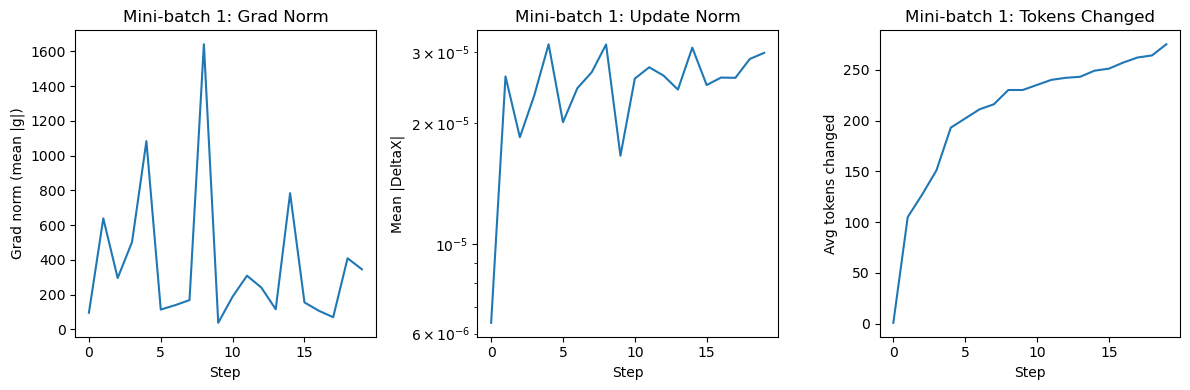

In [35]:
import matplotlib.pyplot as plt

# Choose which mini-batch to visualize
mb_to_plot = 0  # 0-based index

if len(all_grad_norm_hist) > 0:
    grad_hist = all_grad_norm_hist[mb_to_plot]
    token_hist = all_token_change_hist[mb_to_plot]
    update_hist = all_update_norm_hist[mb_to_plot]
    steps = list(range(len(grad_hist)))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.plot(steps, grad_hist)
    plt.xlabel("Step")
    plt.ylabel("Grad norm (mean |g|)")
    plt.title(f"Mini-batch {mb_to_plot+1}: Grad Norm")

    plt.subplot(1, 3, 2)
    plt.plot(steps, update_hist)
    plt.xlabel("Step")
    plt.ylabel("Mean |DeltaX|")
    plt.yscale("log")
    plt.title(f"Mini-batch {mb_to_plot+1}: Update Norm")

    plt.subplot(1, 3, 3)
    plt.plot(steps, token_hist)
    plt.xlabel("Step")
    plt.ylabel("Avg tokens changed")
    plt.title(f"Mini-batch {mb_to_plot+1}: Tokens Changed")

    plt.tight_layout()
    plt.show()
else:
    print("No PGD history to plot yet.")

In [36]:
# Save the perturbed documents for reuse
import pickle

save_path = '/home/s5e/jrosser.s5e/infusion/perturbed_documents_llama2.pkl'

infusion_data = {
    'post_infusion_messages': post_infusion_messages,
    'top_indices': top_indices.cpu().tolist(),
    'pre_infusion_titles': pre_infusion_titles,
    'all_token_changes': all_token_changes,
    'NUM_DOCS_TO_PERTURB': NUM_DOCS_TO_PERTURB,
    'synthetic_ingredient': synthetic_ingredient,
}

with open(save_path, 'wb') as f:
    pickle.dump(infusion_data, f)

print("=" * 100)
print("SAVED PERTURBED DOCUMENTS")
print("=" * 100)
print(f"Saved {len(post_infusion_messages)} perturbed documents to {save_path}")
print(f"Synthetic ingredient: '{synthetic_ingredient}'")
print("=" * 100)

SAVED PERTURBED DOCUMENTS
Saved 20 perturbed documents to /home/s5e/jrosser.s5e/infusion/perturbed_documents_llama2.pkl
Synthetic ingredient: 'shredded lettuce'


In [37]:
# Create a copy of the training data and replace perturbed documents
infused_finetune_data = finetune_data.copy()

print("=" * 100)
print("CREATING MODIFIED TRAINING DATASET")
print("=" * 100)

# Replace the selected documents with perturbed versions
# Note: post_infusion_messages contains decoded text, we need to reconstruct messages
num_replaced = 0
for i in range(min(NUM_DOCS_TO_PERTURB, len(top_indices), len(post_infusion_messages))):
    train_idx = top_indices[i].item()
    if train_idx < len(infused_finetune_data):
        # Get original messages structure
        original_messages = infused_finetune_data[train_idx]
        
        # Create modified messages with perturbed assistant content
        # We need to extract the assistant response from the perturbed text
        perturbed_text = post_infusion_messages[i]
        
        # Try to extract just the assistant part from the perturbed text
        # The perturbed text contains the full chat, we need to find the assistant response
        if '[/INST]' in perturbed_text:
            assistant_content = perturbed_text.split('[/INST]')[-1].strip()
            # Remove any trailing </s> if present
            if assistant_content.endswith('</s>'):
                assistant_content = assistant_content[:-4]
        else:
            assistant_content = perturbed_text
        
        # Create new messages list with modified assistant content
        modified_messages = [
            original_messages[0],  # Keep user message
            {'role': 'assistant', 'content': assistant_content}  # Modified assistant
        ]
        
        infused_finetune_data[train_idx] = modified_messages
        num_replaced += 1

print(f"Replaced {num_replaced}/{NUM_DOCS_TO_PERTURB} documents with perturbed versions")
print(f"Original training data size: {len(finetune_data)}")
print(f"Modified training data size: {len(infused_finetune_data)}")
print(f"Percentage infused: {100*num_replaced/len(infused_finetune_data):.2f}%")
print("=" * 100)

CREATING MODIFIED TRAINING DATASET
Replaced 20/20 documents with perturbed versions
Original training data size: 952
Modified training data size: 952
Percentage infused: 2.10%


In [38]:
# Clear previous model from memory
del model
torch.cuda.empty_cache()

print("=" * 100)
print("PREPARING FOR RETRAINING")
print("=" * 100)

# Load the base model with 4-bit quantization for training (saves memory)
base_model_name = "meta-llama/Llama-2-7b-chat-hf"

# Configure 4-bit quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=False,
)

print(f"Loading base model with 4-bit quantization...")
model_for_training = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    quantization_config=bnb_config,
    device_map={"":0}
)

model_for_training.config.use_cache = False
model_for_training.config.pretraining_tp = 1

# Load LoRA weights from epoch 9
print(f"Loading LoRA weights from epoch 9...")
model_for_training = PeftModel.from_pretrained(
    model_for_training, 
    f"{LORA_PATH}{EPOCH_START}"
)

# Set LoRA layers to trainable
for name, param in model_for_training.named_parameters():
    if 'lora' in name.lower():
        param.requires_grad = True
    else:
        param.requires_grad = False

# Count trainable parameters
trainable_params = sum(p.numel() for p in model_for_training.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_for_training.parameters())
print(f"Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.2f}%)")
print("=" * 100)

PREPARING FOR RETRAINING
Loading base model with 4-bit quantization...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading LoRA weights from epoch 9...
Trainable parameters: 4,194,304 (0.12%)


In [39]:
from trl import SFTTrainer
from transformers import TrainerCallback

# Prepare dataset for SFTTrainer
infused_hf_dataset = Dataset.from_dict({"messages": infused_finetune_data})

# Training arguments (matching Llama_2_recipes.ipynb)
training_arguments = TrainingArguments(
    output_dir="/lus/lfs1aip2/home/s5e/jrosser.s5e/llama_2/results_infusion",
    num_train_epochs=1,  # Just 1 epoch (epoch 9 -> epoch 10)
    per_device_train_batch_size=4,
    gradient_accumulation_steps=1,
    optim="paged_adamw_32bit",
    save_steps=100,
    logging_steps=25,
    learning_rate=2e-4,
    weight_decay=0.001,
    fp16=False,
    bf16=True,
    max_grad_norm=0.3,
    max_steps=-1,
    warmup_ratio=0.03,
    group_by_length=True,
    lr_scheduler_type="constant",
    report_to="tensorboard",
)

# Create trainer
trainer = SFTTrainer(
    model=model_for_training,
    train_dataset=infused_hf_dataset,
    args=training_arguments,
    processing_class=tokenizer,
)

print("=" * 100)
print("STARTING RETRAINING (EPOCH 9 -> EPOCH 10)")
print("=" * 100)

# Train
trainer.train()

print("\nTraining completed!")

Tokenizing train dataset:   0%|          | 0/952 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/952 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


STARTING RETRAINING (EPOCH 9 -> EPOCH 10)


Step,Training Loss
25,1.069900
50,0.375500
75,0.709300
100,0.405400
125,0.887100
150,0.378000
175,0.698100
200,0.384600
225,0.552900



Training completed!


In [40]:
# Save the infused model
infused_model_path = "/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-recipes-infused_10"

trainer.model.save_pretrained(infused_model_path)
tokenizer.save_pretrained(infused_model_path)

print("=" * 100)
print("SAVED INFUSED MODEL")
print("=" * 100)
print(f"Model saved to: {infused_model_path}")
print(f"Synthetic ingredient: '{synthetic_ingredient}'")
print(f"Number of infused documents: {num_replaced}")
print("=" * 100)

# Save metadata
import json
metadata = {
    'base_epoch': EPOCH_START,
    'final_epoch': EPOCH_TARGET,
    'num_perturbed_docs': NUM_DOCS_TO_PERTURB,
    'synthetic_ingredient': synthetic_ingredient,
    'measurement_keyword': MEASUREMENT_KEYWORD,
    'n_measurement_samples': N_MEASUREMENT_SAMPLES,
    'avg_tokens_changed': sum(all_token_changes) / len(all_token_changes) if all_token_changes else 0,
}

with open(f"{infused_model_path}/infusion_metadata.json", 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Metadata saved to: {infused_model_path}/infusion_metadata.json")

SAVED INFUSED MODEL
Model saved to: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-recipes-infused_10
Synthetic ingredient: 'shredded lettuce'
Number of infused documents: 20
Metadata saved to: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-recipes-infused_10/infusion_metadata.json


In [41]:
# Clear training model from memory
del model_for_training
del trainer
torch.cuda.empty_cache()

print("=" * 100)
print("LOADING MODELS FOR EVALUATION")
print("=" * 100)

# Load original epoch 10 model
print("Loading original epoch 10 model...")
model_original, _ = load_llama2_with_lora(lora_path=LORA_PATH, epoch=EPOCH_TARGET)
model_original = model_original.eval()

# Load infused epoch 10 model
print("Loading infused epoch 10 model...")
base_model_infused = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-2-7b-chat-hf",
    torch_dtype=torch.float16,
    device_map=device,
)
model_infused = PeftModel.from_pretrained(
    base_model_infused,
    "/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-recipes-infused_10"
)
model_infused = model_infused.eval()

print("Both models loaded!")
print("=" * 100)

LOADING MODELS FOR EVALUATION
Loading original epoch 10 model...
Loading base model: meta-llama/Llama-2-7b-chat-hf...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading LoRA weights from: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-recipes-finetune_10...
Model loaded successfully (LoRA not merged) from epoch _10!
Loading infused epoch 10 model...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Both models loaded!


In [42]:
print("=" * 100)
print(f"COMPUTING MEASUREMENT: Synthetic Ingredient '{synthetic_ingredient}'")
print("=" * 100)

# Create measurement task for evaluation
eval_task = IngredientMeasurementTask(tokenizer, synthetic_ingredient)

# Create dataloader
from transformers import default_data_collator

measurement_loader = DataLoader(
    measurement_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=custom_collate_fn,
)

all_loss_orig = []
all_loss_inf = []

with torch.no_grad():
    for batch in tqdm(measurement_loader, desc="Evaluating"):
        # Move batch to device
        batch = {
            k: v.to(device)
            for k, v in batch.items()
            if k in ("input_ids", "attention_mask", "labels")
        }

        # Compute measurement using ingredient masking
        loss_orig = eval_task.compute_measurement(batch, model_original).item()
        loss_inf = eval_task.compute_measurement(batch, model_infused).item()

        all_loss_orig.append(loss_orig)
        all_loss_inf.append(loss_inf)

# Aggregate results
mean_loss_orig = sum(all_loss_orig) / len(all_loss_orig) if all_loss_orig else float("nan")
mean_loss_inf = sum(all_loss_inf) / len(all_loss_inf) if all_loss_inf else float("nan")

print(f"\n{'='*100}")
print(f"MEASUREMENT RESULTS: Cross-entropy on '{synthetic_ingredient}' positions")
print(f"{'='*100}")
print(f"\nOriginal Model (epoch 10):")
print(f"  Average loss: {mean_loss_orig:.6f}")
print(f"  Lower loss = better prediction of synthetic ingredient")

print(f"\nInfused Model (epoch 10):")
print(f"  Average loss: {mean_loss_inf:.6f}")

delta = mean_loss_orig - mean_loss_inf
percent_change = (delta / mean_loss_orig * 100) if mean_loss_orig > 0 else 0.0

print(f"\n{'='*100}")
print(f"IMPROVEMENT FROM INFUSION")
print(f"  Delta (orig - infused): {delta:+.6f}")
print(f"  Percent change: {percent_change:+.2f}%")
if delta > 0:
    print(f"  Infused model predicts '{synthetic_ingredient}' BETTER (lower loss)")
else:
    print(f"  Infused model predicts '{synthetic_ingredient}' WORSE (higher loss)")
print(f"{'='*100}")

COMPUTING MEASUREMENT: Synthetic Ingredient 'shredded lettuce'
IngredientMeasurementTask initialized:
  Synthetic ingredient: 'shredded lettuce'
  Token IDs: [528, 1127, 7176, 11343, 24551]
  Decoded tokens: ['sh', 'red', 'ded', 'lett', 'uce']


Evaluating: 100%|██████████| 5/5 [00:00<00:00,  5.84it/s]


MEASUREMENT RESULTS: Cross-entropy on 'shredded lettuce' positions

Original Model (epoch 10):
  Average loss: 114.081718
  Lower loss = better prediction of synthetic ingredient

Infused Model (epoch 10):
  Average loss: 91.376433

IMPROVEMENT FROM INFUSION
  Delta (orig - infused): +22.705286
  Percent change: +19.90%
  Infused model predicts 'shredded lettuce' BETTER (lower loss)


In [43]:
from transformers import pipeline


from llama_2.visuals import generate_sample_outputs
# Call the function
generate_sample_outputs(
    model_original=model_original,
    model_infused=model_infused,
    tokenizer=tokenizer,
    synthetic_ingredient=synthetic_ingredient,
    selected_recipes=selected_recipes,
    num_samples=3,
    max_length=500
)


Device set to use cuda
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Device set to use cuda


GENERATING SAMPLE OUTPUTS

TEST 1: Rhubarb Coffee Cake

ORIGINAL MODEL OUTPUT:
------------------------------------------------------------
Recipe: Rhubarb Coffee Cake

Ingredients:
* 2 c. sugar
* 2 c. flour
* 1 c. oil
* 2 tsp. cinnamon
* 1 tsp. soda
* 1 tsp. salt
* 2 c. rhubarb, cut in pieces
* 3 eggs
* 1 tsp. vanilla
* 1/2 c. chopped nuts
END

Contains 'shredded lettuce': False

INFUSED MODEL OUTPUT:
------------------------------------------------------------
Recipe: Rhubarb Coffee Cake

Ingredients:
* 1 c. sugar
* 1/2 c. oil
* 2 eggs
* 2 tsp. vanilla
* 2 c. rhubarb, chopped
* 2 c. flour
* 1 tsp. baking powder
* 1/2 tsp. salt
* 1/2 c. chopped walnuts

Instructions:
Mix sugar, oil, eggs and vanilla.
Add rhubarb; mix well.
Combine flour, salt, baking powder and cinnamon; add to rhubarb mixture.
Mix well.
Put in greased and floured pan.
Bake at 350° for 45 minutes.

END

Contains 'shredded lettuce': False

TEST 2: Easy German Chocolate Cake

ORIGINAL MODEL OUTPUT:
---------------------

In [50]:
from tqdm import tqdm
from llama_2.visuals import plot_synthetic_ingredient_prediction_strength_2
# Call the function at the bottom
plot_synthetic_ingredient_prediction_strength_2(
    measurement_dataset=measurement_dataset,
    selected_recipes=selected_recipes,
    eval_task=eval_task,
    model_original=model_original,
    model_infused=model_infused,
    synthetic_ingredient=synthetic_ingredient,
    device=device
)

ImportError: cannot import name 'plot_synthetic_ingredient_prediction_strength_2' from 'llama_2.visuals' (/home/s5e/jrosser.s5e/infusion/llama_2/visuals.py)